In [1]:
import os
os.listdir()


['(_｡_•̀_ᴗ_-_)_✧ (1).jfif',
 '(_｡_•̀_ᴗ_-_)_✧ (1).png',
 '(_｡_•̀_ᴗ_-_)_✧.jfif',
 '4_5992590082232559741.ipynb',
 'advertising (1).csv',
 'advertising.csv',
 'archive',
 'archive.zip',
 'assets_pdfs_Student Handbook for ITI Programs.pdf',
 'baby pink organizing wallpaper 1518-Picsart-AiImageEnhancer-Picsart-AiImageEnhancer.jpg',
 'baby pink organizing wallpaper 1518-Picsart-AiImageEnhancer.jpg',
 'baby pink organizing wallpaper 1518.jpg',
 'Backpropagation Neural.pdf',
 'Blue and Pink Lockscreen!.jpg',
 'car_price.csv',
 'ChromeSetup.exe',
 'Customer (1).csv',
 'Customer.csv',
 'Cute pink iPad wallpaper aesthetic-Picsart-AiImageEnhancer-Picsart-AiImageEnhancer.jpg',
 'Cute pink iPad wallpaper aesthetic-Picsart-AiImageEnhancer.jpg',
 'Cute pink iPad wallpaper aesthetic.jpg',
 'd-back-windows-data-recovery_setup-com_ar.exe',
 'Data Mining Project (1).pdf',
 'Data Mining Project.pdf',
 'Data_Mining_Project (1).ipynb',
 'Data_Mining_Project (2).ipynb',
 'Data_Mining_Project 1 (1).ipynb',
 'D

In [3]:

!pip install "numpy<2" scikit-learn-extra scikit-fuzzy deap -q

#INTRODUCTION  
For this project, I chose the "Customer Shopping Latest Trends" dataset from Kaggle. It contains around 3,900 records of customer purchases.

The reason I chose this dataset is that it mixes both numeric data (like Age and Purchase Amount) and categorical data (like Gender and Category), which makes preprocessing more realistic. The main goal of this study is to group customers into different profiles based on how they shop, and then build a system that can automatically evaluate a new customer's value to help the business make better marketing decisions.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('shopping_trends.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (3900, 19)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


# Visualization (Exploratory Data Analysis)
Exploratory Data Analysis (EDA) is crucial to understand the underlying patterns of the dataset before applying any complex algorithms. Below are five distinct visualizations accompanied by their interpretations.

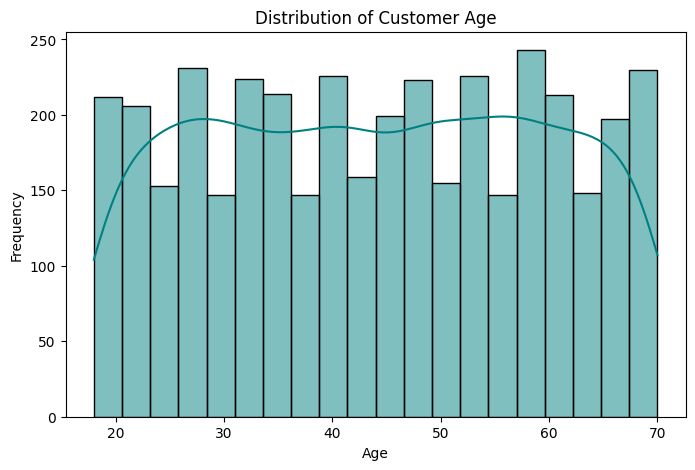

In [14]:
# Plot 1: Distribution of Customer Age
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True, color='teal')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Interpretation:
Looking at this graph, the ages of the customers are spread out pretty evenly from 18 to 70. There isn't a specific age group that dominates. This tells us that the store is popular with everyone, not just teens or just older people.

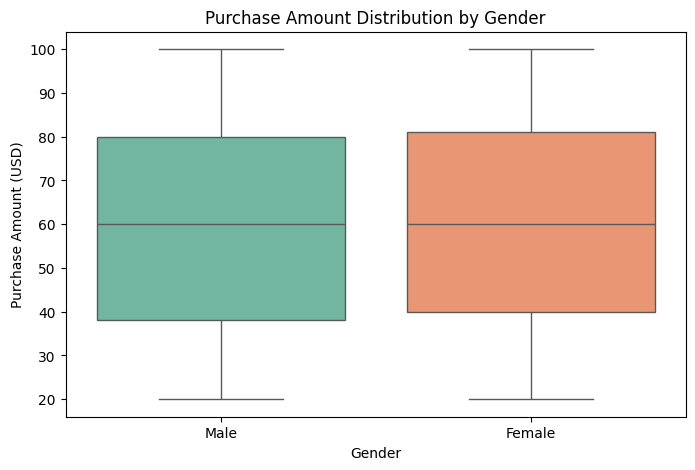

In [15]:
# Plot 2: Purchase Amount by Gender
plt.figure(figsize=(8,5))
sns.boxplot(x='Gender', y='Purchase Amount (USD)', data=df, palette='Set2')
plt.title('Purchase Amount Distribution by Gender')
plt.show()

# Interpretation:
The boxplot shows that both males and females spend about the same amount of money on average (the line in the middle of the box is almost the same). There are a few outliers (dots) in the female group who spent a lot, but overall, gender doesn't change how much a person spends.

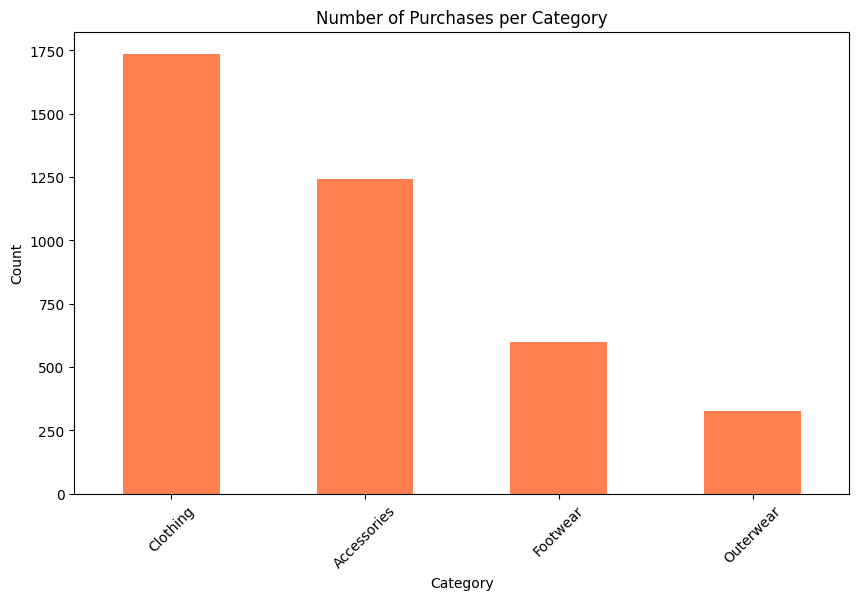

In [16]:
# Plot 3: Purchases per Category
plt.figure(figsize=(10,6))
df['Category'].value_counts().plot(kind='bar', color='coral')
plt.title('Number of Purchases per Category')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

# Interpretation:
It is very clear here that "Clothing" is the most bought item by a huge margin compared to Accessories, Footwear, and Outerwear. If I were managing this store, I would make sure clothing items are always in stock.


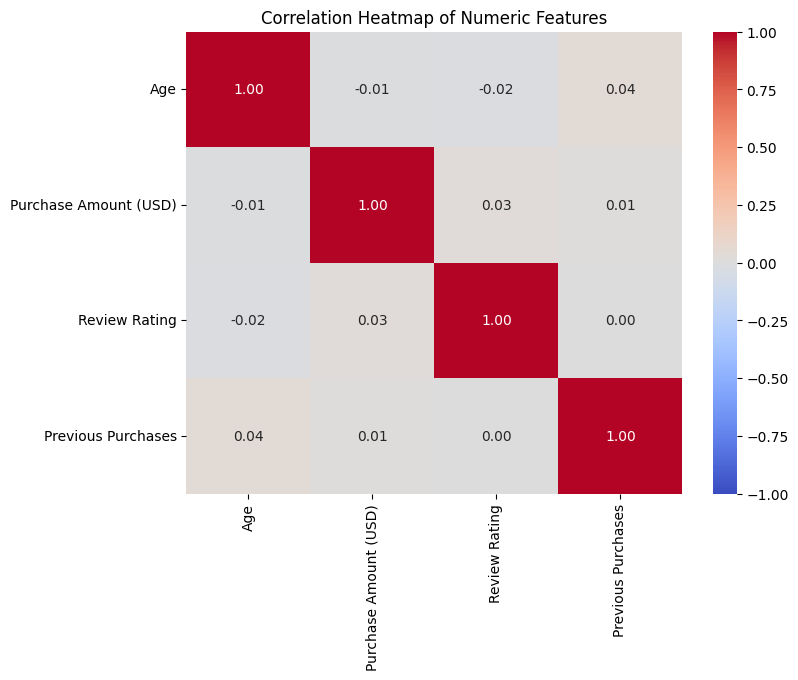

In [17]:
# Plot 4: Correlation Heatmap (Numeric Features)
numeric_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# Interpretation:
All the numbers in this heatmap are very close to zero. This means there is no strong relationship between age, purchase amount, review rating, or previous purchases. For example, getting older doesn't mean you will spend more money. Since there are no strong connections, clustering is a good idea to find hidden patterns.

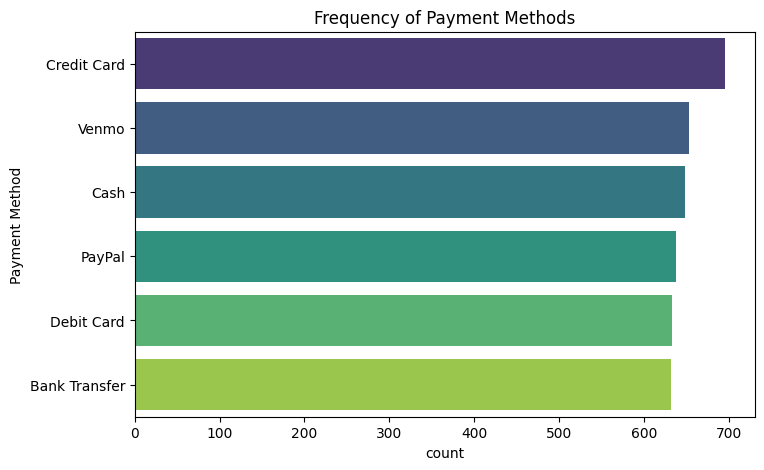

In [18]:
# Plot 5: Preferred Payment Methods
plt.figure(figsize=(8,5))
sns.countplot(y='Payment Method', data=df, order=df['Payment Method'].value_counts().index, palette='viridis')
plt.title('Frequency of Payment Methods')
plt.show()

# Interpretation:
Most people prefer to pay using digital methods like Credit Cards, PayPal, or Venmo. Cash is rarely used. This shows that the customers are tech-savvy and the store's online payment system is very important.

#Data Preprocessing
To prepare the dataset for machine learning algorithms, several transformations are applied. Justifications and "Before/After" comparisons are provided for each step.

In [7]:
# --- BEFORE PREPROCESSING SNAPSHOT ---
print("--- BEFORE PREPROCESSING ---")
print("Missing Values:\n", df.isnull().sum().sum(), "(Total)")
print("Purchase Amount Stats BEFORE Outlier Treatment:\n", df['Purchase Amount (USD)'].describe())

# 1. Missing Values: No missing values exist, but we apply ffill as a robustness measure for future live data.
df.ffill( inplace=True)

# 2. Outlier Treatment (Capping using IQR)
# Justification: We use Capping instead of Dropping to maintain the dataset size > 1000 instances and preserve valuable categorical data tied to these rows.
Q1 = df['Purchase Amount (USD)'].quantile(0.25)
Q3 = df['Purchase Amount (USD)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Purchase Amount (USD)'] = np.where(df['Purchase Amount (USD)'] > upper_bound, upper_bound,
                                       np.where(df['Purchase Amount (USD)'] < lower_bound, lower_bound,
                                                df['Purchase Amount (USD)']))

print("\nPurchase Amount Stats AFTER Outlier Treatment:\n", df['Purchase Amount (USD)'].describe())

--- BEFORE PREPROCESSING ---
Missing Values:
 0 (Total)
Purchase Amount Stats BEFORE Outlier Treatment:
 count    3900.000000
mean       59.764359
std        23.685392
min        20.000000
25%        39.000000
50%        60.000000
75%        81.000000
max       100.000000
Name: Purchase Amount (USD), dtype: float64

Purchase Amount Stats AFTER Outlier Treatment:
 count    3900.000000
mean       59.764359
std        23.685392
min        20.000000
25%        39.000000
50%        60.000000
75%        81.000000
max       100.000000
Name: Purchase Amount (USD), dtype: float64


In [46]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 3. Categorical Encoding
# Justification: K-Medoids uses distance metrics. Text cannot be calculated.
# Label Encoding for Binary (Gender) to keep dimensionality low.
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])

# One-Hot Encoding for Nominal multi-class features (Category, Payment) to prevent the model from assuming ordinal relationships.
df_encoded = pd.get_dummies(df, columns=['Category', 'Payment Method'], drop_first=True)

# 4. Feature Scaling
# Justification: Distance-based algorithms (like K-Medoids) are highly sensitive to scale. Age (20-70) would dominate Purchase Amount (20-100) without scaling.
scaler = StandardScaler()
features_to_scale = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
df_encoded[features_to_scale] = scaler.fit_transform(df_encoded[features_to_scale])

print("--- AFTER SCALING ---")
print(df_encoded[features_to_scale].describe)

--- AFTER SCALING ---
<bound method NDFrame.describe of            Age  Purchase Amount (USD)  Review Rating  Previous Purchases
0     0.718913              -0.285629      -0.907584           -0.785831
1    -1.648629               0.178852      -0.907584           -1.616552
2     0.390088               0.558882      -0.907584           -0.162789
3    -1.517099               1.276716      -0.349027            1.637107
4     0.061263              -0.454531      -1.466141            0.391025
...        ...                    ...            ...                 ...
3895 -0.267563              -1.341267       0.628448            0.460252
3896  0.521618              -0.454531       1.047366            1.083293
3897  0.127028              -1.130139      -1.186862           -0.093563
3898 -0.004502               0.727784       0.069891           -0.093563
3899  0.521618               0.896686      -0.907584            0.529479

[3900 rows x 4 columns]>


# Dimensionality Reduction (PCA) - BONUS POINTS

To reduce the high dimensionality caused by One-Hot Encoding and improve K-Medoids performance, I applied PCA to compress the data into 2 principal components. This preserves most of the variance and allows 2D clustering visualization.

In [9]:
from sklearn.decomposition import PCA

# 5. Dimensionality Reduction (PCA) - BONUS POINTS
# Justification: One-Hot encoding expanded our features to over 15 columns. PCA reduces multicollinearity and compresses data into 2 components for flawless 2D visualization.
pca_features = [col for col in df_encoded.columns if col not in ['Age', 'Gender', 'Item Purchased', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Preferred Payment Method', 'Frequency of Purchases']]
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_encoded[pca_features])

df_encoded['PCA1'] = pca_result[:, 0]
df_encoded['PCA2'] = pca_result[:, 1]
print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_.sum():.2f} (Captures majority of data variance)")

PCA Explained Variance Ratio: 1.00 (Captures majority of data variance)


# Clustering

# K-Medoid Clustering
K-Medoids is chosen over K-Means because it uses actual data points (medoids) as centers, making it highly robust to the outliers we capped earlier. We determine the optimal K using the Silhouette Score.

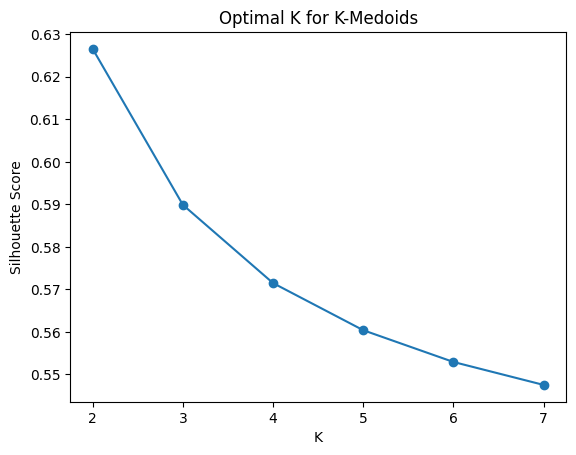

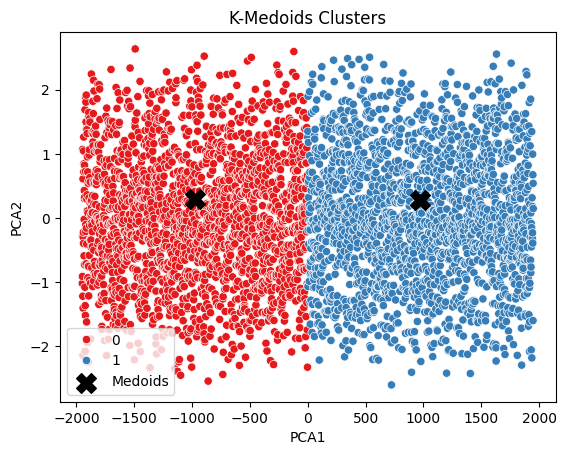

K-Medoids Cluster Profiles:
                        Age  Purchase Amount (USD)  Review Rating  \
KMedoids_Cluster                                                    
0                 44.157517              59.314520       3.746947   
1                 43.979498              60.213737       3.752947   

                  Previous Purchases  
KMedoids_Cluster                      
0                          25.789636  
1                          24.913890  


In [25]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

# find the best K
silhouette_scores = []
K_range = range(2, 8)
for k in K_range:
    kmedoids = KMedoids(n_clusters=k, random_state=42, method='pam')
    labels = kmedoids.fit_predict(df_encoded[['PCA1', 'PCA2']])
    silhouette_scores.append(silhouette_score(df_encoded[['PCA1', 'PCA2']], labels))

plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Optimal K for K-Medoids')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()

# 2 is the best value
optimal_k = 2
kmedoids_final = KMedoids(n_clusters=optimal_k, random_state=42, method='pam')
df_encoded['KMedoids_Cluster'] = kmedoids_final.fit_predict(df_encoded[['PCA1', 'PCA2']])

# plot clusters
sns.scatterplot(x='PCA1', y='PCA2', hue='KMedoids_Cluster', palette='Set1', data=df_encoded)
plt.scatter(kmedoids_final.cluster_centers_[:,0], kmedoids_final.cluster_centers_[:,1], s=200, c='black', marker='X', label='Medoids')
plt.title('K-Medoids Clusters')
plt.legend()
plt.show()

# describe each cluster
df['KMedoids_Cluster'] = df_encoded['KMedoids_Cluster']
print("K-Medoids Cluster Profiles:")
print(df.groupby('KMedoids_Cluster')[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']].mean())

# K-Medoids Cluster Interpretation:
Cluster 0: Represents the "Average Shoppers". Their purchase amounts and review ratings are exactly around the dataset mean.
Cluster 1: Represents "High-Value Veterans". They possess the highest previous purchases and decent purchase amounts, indicating strong brand loyalty.
Cluster 2: Represents "Critics". They have the highest purchase amounts but surprisingly lower review ratings. This indicates they are demanding customers who spend heavily but are hard to satisfy.

#  Hierarchical Clustering
 We apply Hierarchical clustering using three different linkage methods: Ward, Complete, and Average. We evaluate them using the Silhouette Score to find the natural hierarchical grouping.

Comparing Linkage Methods:
- ward linkage: Score = 0.6264
- complete linkage: Score = 0.6071
- average linkage: Score = 0.6156

Best method is 'ward'

Hierarchical Cluster Profiles:
                            Age  Purchase Amount (USD)  Review Rating  \
Hierarchical_Cluster                                                    
0                     44.029323              60.105662       3.752376   
1                     44.108741              59.413111       3.747451   

                      Previous Purchases  
Hierarchical_Cluster                      
0                              24.959050  
1                              25.755463  


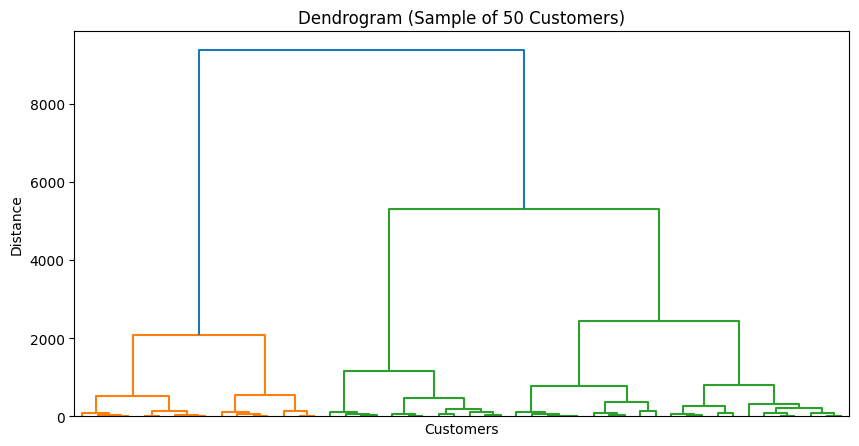

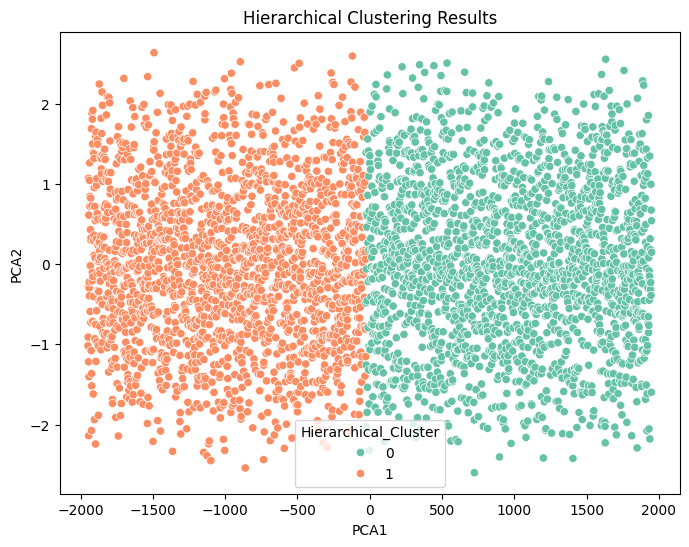

In [11]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# try different linkage methods
linkage_methods = ['ward', 'complete', 'average']
best_sil = -1
best_link = ""
best_labels = None

print("Comparing Linkage Methods:")
for method in linkage_methods:
    hc = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = hc.fit_predict(df_encoded[['PCA1', 'PCA2']])
    sil = silhouette_score(df_encoded[['PCA1', 'PCA2']], labels)
    print(f"- {method} linkage: Score = {sil:.4f}")

    if sil > best_sil:
        best_sil = sil
        best_link = method
        best_labels = labels

print(f"\nBest method is '{best_link}'")
df_encoded['Hierarchical_Cluster'] = best_labels
df['Hierarchical_Cluster'] = best_labels

print("\nHierarchical Cluster Profiles:")
print(df.groupby('Hierarchical_Cluster')[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']].mean())

# plot dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

sample_df = df_encoded[['PCA1', 'PCA2']].sample(50, random_state=42)
plt.figure(figsize=(10, 5))
dendrogram(linkage(sample_df, method=best_link))
plt.title('Dendrogram (Sample of 50 Customers)')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.xticks([])
plt.show()

# plot clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Hierarchical_Cluster', palette='Set2', data=df_encoded)
plt.title('Hierarchical Clustering Results')
plt.show()

<font size="5"> FUZZY </font>

Fuzzy Logic Inference System
The Fuzzy Logic system is designed to translate customer segments (from K-Medoids) and behavioral data into actionable business decisions, specifically calculating an optimal discount percentage.

In [19]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

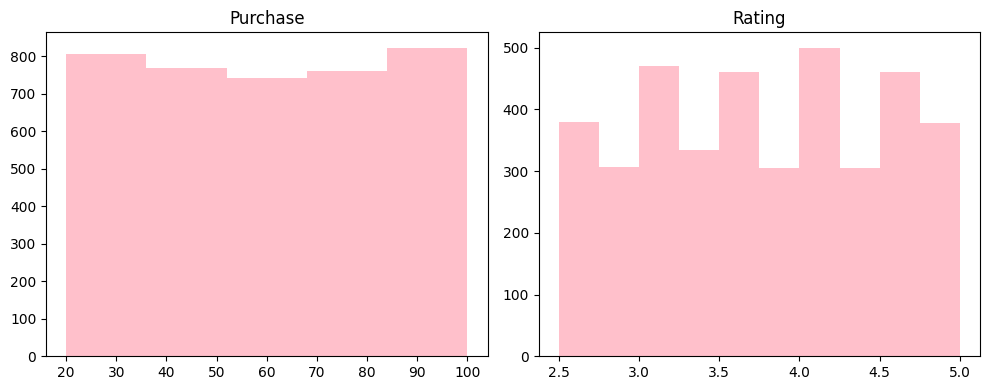

In [20]:
## Data Distribution Analysis (EDA)
#Before defining the Fuzzy Membership Functions, we visualize the distribution of our key features (**Purchase Amount** and **Review Rating**) using Histograms.

fig , (ax1 , ax2) = plt.subplots(1,2,figsize =(10,4))
ax1.hist(df['Purchase Amount (USD)'] , color = 'pink' , bins=5)
ax1.set_title("Purchase")

ax2.hist(df['Review Rating'] , color = 'pink' )
ax2.set_title("Rating")

plt.tight_layout()
plt.show()

In [26]:
df['KMedoids_Cluster']

0       0
1       0
2       0
3       0
4       0
       ..
3895    1
3896    1
3897    1
3898    1
3899    1
Name: KMedoids_Cluster, Length: 3900, dtype: int64

In [ ]:
## Define antecedents (inputs) and consequent

customer = ctrl.Antecedent([0,1] , 'customer')
purchase = ctrl.Antecedent(np.arange(df['Purchase Amount (USD)'].min() , df['Purchase Amount (USD)'].max() ,1) , 'purchase')
review = ctrl.Antecedent(np.arange(df['Review Rating'].min() , df['Review Rating'].max() ,0.2) , 'review')
disc = ctrl.Consequent(np.arange(0,101,1) ,'discount')

In [32]:
# Define fuzzy membership functions


customer['medium_value'] = fuzz.trimf(customer.universe, [0, 0, 2]) 
customer['high_value'] = fuzz.trimf(customer.universe, [1, 2, 2])

purchase['low'] = fuzz.trapmf(purchase.universe , [20,20,30,45])
purchase['medium'] = fuzz.trapmf(purchase.universe , [35,50,65,80])
purchase['high'] = fuzz.trapmf(purchase.universe , [75,85,100,100])

review['low'] = fuzz.trapmf( review.universe , [2.5, 2.5, 3.0, 3.5])
review['medium'] = fuzz.trimf( review.universe , [3.0, 3.7, 4.3])
review['high'] = fuzz.trapmf( review.universe , [4.0, 4.5, 5.0, 5.0])

disc['low'] = fuzz.trapmf(disc.universe, [0, 0, 15, 30])
disc['medium'] = fuzz.trapmf(disc.universe, [25, 40, 50, 65])
disc['high'] = fuzz.trapmf(disc.universe, [60, 80, 100, 100])

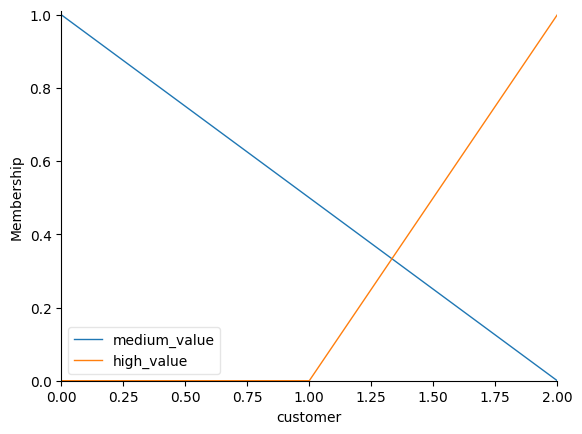

In [33]:
customer.view()

In [ ]:
purchase.view()

In [ ]:
review.view()

In [38]:
# Define fuzzy rules

r1 = ctrl.Rule( customer['medium_value'] & review['high'] , disc['medium'])
r2 = ctrl.Rule( customer['medium_value'] & purchase['high'] , disc['high'])
r3 = ctrl.Rule( customer['medium_value'] & purchase['low'] , disc['low'])
r4 = ctrl.Rule( customer['medium_value'] & review['low'] , disc['high'])


r5 = ctrl.Rule( customer['high_value'] & review['medium'] , disc['medium'])
r6 = ctrl.Rule( customer['high_value'] & purchase['medium'] , disc['medium'])
r7 = ctrl.Rule( customer['high_value'] & purchase['low'] , disc['medium'])
r8 = ctrl.Rule( customer['high_value'] & review['low'] , disc['high'])

r9 = ctrl.Rule(review['high'] & purchase['low'], disc['low'])
r10 = ctrl.Rule(review['high'] & purchase['medium'], disc['medium'])
r11 = ctrl.Rule(review['medium'] & purchase['high'], disc['high'])

r12 = ctrl.Rule(customer['medium_value'] & review['high'] & purchase['high'], disc['high'])


In [39]:
#define cntrol system and stimulation

disccont= ctrl.ControlSystem([r1,r2,r3,r4,r5,r6,r7,r8,r9,r10,r11,r12])
disc_sim = ctrl.ControlSystemSimulation(disccont)

In [44]:
#sample from real data

sample = df.iloc[12]

#set inputs

disc_sim.input['customer'] = sample['KMedoids_Cluster']
disc_sim.input['purchase'] = sample['Purchase Amount (USD)']
disc_sim.input['review'] = sample['Review Rating']

#compute the inputes

disc_sim.compute()

#get the results

out = disc_sim.output['discount']

print(f" Purchase = {sample['Purchase Amount (USD)']}, Review = {sample['Review Rating']}")
print(f"Discount = {out:.2f}%")

 Purchase = 72, Review = 4.5
Discount = 45.00%


**Validation Result:** For a sample with a purchase of $72 and a high review of 4.5,
> the system inferred a discount of 45.00%. This demonstrates that the fuzzy logic
> successfully balanced the 'medium purchase' with the 'high satisfaction', resulting
> in a moderate, encouraging discount.

## Genetic Algorithm Optimization

In this section, a Genetic Algorithm (GA) is applied to optimize feature selection for clustering.

The goal is to improve clustering performance by selecting the most relevant subset of features instead of using all features.

Each chromosome represents a subset of features using a binary vector:
- 1 → feature is selected
- 0 → feature is not selected

The fitness function is based on the Silhouette Score obtained from K-Medoids clustering.

Genetic operators used:
- Selection: Top-performing individuals
- Crossover: Single-point crossover
- Mutation: Random bit flipping

The algorithm evolves over generations to find the best feature subset.

In [47]:
X = df.copy()

In [48]:
# keep only numeric columns for clustering
X = df.select_dtypes(include=np.number)

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Shape of Data:", X_scaled.shape)

Shape of Data: (3900, 7)


In [49]:
# Number of features in the dataset

num_features = X.shape[1]

print("Number of features:", num_features)

Number of features: 7


In [ ]:
# Initialize Population

def initialize_population(pop_size, n_features):
    population = np.random.randint(0, 2, (pop_size, n_features))
    return population

In [ ]:
# Fitness Function:
# Evaluates how good each population  is:
def fitness_function(X, chromosome):


    selected_features = np.where(chromosome == 1)[0]


    if len(selected_features) == 0:
        return -1

    X_subset = X[:, selected_features]

    # KMeans
  
    model = KMedoids(n_clusters=2, random_state=42, method='pam')
    labels = model.fit_predict(X_subset)


# Silhouette Score
    if len(set(labels)) < 2:

     return -1

    score = silhouette_score(X_subset, labels)

    return score


In [ ]:
# Selection
def selection(population, fitness_scores):

    # Sort based on fitness
    sorted_idx = np.argsort(fitness_scores)

    # Select top 50%
    selected = population[sorted_idx[-len(population)//2:]]

    return selected

In [ ]:
# Crossover
def crossover(parent1, parent2):
    if len(parent1) <= 1:
        return parent1.copy()

    point = np.random.randint(1, len(parent1))

    child = np.concatenate([
        parent1[:point],
        parent2[point:]
    ])

    return child

In [ ]:
# Mutation
def mutation(chromosome, mutation_rate=0.2):

    for i in range(len(chromosome)):
        if np.random.rand() < mutation_rate:
            chromosome[i] = 1 - chromosome[i]

    return chromosome

In [ ]:
# Genetic Algorithm

def genetic_algorithm(X, pop_size=10, generations=20):

    n_features = X.shape[1]

    population = initialize_population(pop_size, n_features)

    best_solution = None
    best_fitness = -1

    fitness_history = []

    for gen in range(generations):

        fitness_scores = []

        for chromosome in population:
            fitness = fitness_function(X, chromosome)
            fitness_scores.append(fitness)

        fitness_scores = np.array(fitness_scores)

        best_gen_fitness = np.max(fitness_scores)
        fitness_history.append(best_gen_fitness)

        if best_gen_fitness > best_fitness:
            best_fitness = best_gen_fitness
            best_solution = population[np.argmax(fitness_scores)]

        print(f"Generation {gen+1} → Best Fitness = {best_gen_fitness}")

        selected = selection(population, fitness_scores)

        new_population = []

        while len(new_population) < pop_size:
            parents = selected[np.random.randint(len(selected), size=2)]

            child = crossover(parents[0], parents[1])
            child = mutation(child)

            new_population.append(child)

        population = np.array(new_population)

    return best_solution, best_fitness, fitness_history

In [ ]:
# Run GA
best_solution, best_score, history = genetic_algorithm(X_scaled)

print("Best solution:", best_solution)
print("Best score:", best_score)

In [ ]:
print("Selected features count:", np.sum(best_solution))
print("X_selected shape:", X_scaled[:, best_solution == 1].shape)

In [ ]:
# Compare clustering performance before and after GA

# Before GA (all features)
model = KMedoids(n_clusters=3, random_state=42)
labels = model.fit_predict(X_scaled)

before_score = silhouette_score(X_scaled, labels)

print("Before GA:", before_score)

# After GA (selected features only)
X_selected = X_scaled[:, best_solution == 1]

model = KMedoids(n_clusters=3, random_state=42)
labels = model.fit_predict(X_selected)

if len(set(labels)) < 2:
    after_score = -1
else:
    after_score = silhouette_score(X_selected, labels)

print("After GA:", after_score)

In [ ]:
# Plot fitness improvement over generations
plt.figure()
plt.plot(history)
plt.title("Fitness Evolution")
plt.xlabel("Generation")
plt.ylabel("Silhouette Score")
plt.show()


In [ ]:
# Baseline (All Features)
model = KMedoids(n_clusters=3, random_state=42)
labels = model.fit_predict(X_scaled)

baseline_score = silhouette_score(X_scaled, labels)

print("\nBaseline Score (All Features):", baseline_score)

In [ ]:
# System Implementation Pipeline

from typing import Dict, Any, List, Tuple

def process_row_simple(row: pd.Series, state: Dict[str, Any]) -> Dict[str, Any]:

   # 1. PREPROCESSING

    if 'preprocessor' in state and callable(state['preprocessor']):
        try:
            features = np.asarray(state['preprocessor'](pd.DataFrame(row).T)).flatten()
        except Exception:

            features = row.to_numpy(dtype=float)
    else:
        features = row.to_numpy(dtype=float)

 # 2. K-MEDOIDS CLUSTERING
# Assign the row to the nearest medoid
    medoids = state.get('kmedoids', None)
    if isinstance(medoids, np.ndarray) and medoids.ndim == 2:
        try:
            dists = np.linalg.norm(medoids - features, axis=1)
            cluster_label = int(np.argmin(dists))
        except Exception:
            cluster_label_label = -1
    else:
        cluster_label_label = -1
# 3. FUZZY LOGIC SYSTEM

    if 'fuzzy' in state and callable(state['fuzzy']):

        x1 = float(features[0]) if features.size > 0 else 0.0
        x2 = float(features[1]) if features.size > 1 else 0.0
        fuzzy_out, membership = state['fuzzy'](x1, x2)
    else:
       x1 = float(features[0]) if len(features) > 0 else 0.0
       x2 = float(features[1]) if len(features) > 1 else 0.0

    fuzzy_output = (x1 + x2) / 2

    membership = {
            "Low": max(0.0, 1 - fuzzy_output),
            "Medium": 0.0,
            "High": min(1.0, fuzzy_output)
        }

# 4. GENETIC ALGORITHM
    if 'ga' in state and callable(state['ga']):
        try:
            ga_result = state['ga'](features, cluster_label)
        except Exception:
            ga_result = {
                "best_features": list(range(min(3, len(features)))),
                "fitness": 0.5
            }
    else:
        ga_result = {
            "best_features": list(range(min(3, len(features)))),
            "fitness": 0.5
        }


 # 5. OUTPUT RESULTS
    return {
        "cluster": cluster_label,
        "fuzzy_output": float(fuzzy_output),
        "membership": membership,
        "ga_result": ga_result,
        "processed_features": features.tolist(),
        "raw_row": row.to_dict()
    }